Multi-head attention

In [71]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

In [79]:
def attention(query, key, value, mask=None, dropout=None):
    """Scaled Dot-Product Attention
                     ▲
        ┌────────────┴─────────────┐
        │4) MatMul                 │ ← Attention Weights · V
        └────▲──────────────────▲──┘
        ┌────┴──────┐           │  
        │3) Softmax │           │
        └────▲──────┘           │
       ┌─────┴────────┐         │
       │2) Mask (opt.)│         │
       └─────▲────────┘         │
        ┌────┴──────┐           │
        │1) Scale   │ (/ √d_k)  │
        └────▲──────┘           │
        ┌────┴──────┐           │
        │1) MatMul  │ ← Q · Kᵀ  │
        └────▲──────┘           │
       ┌─────┴─────┐────────────│ 
       Q           K            V
    """
    print(f"+attention")
    d_k = query.size(-1)
    # input: query, key, value shape: (batch_size, h, seq_len, d_k)
    #
    # 1) MatMul(QK^T) + Scale(math.sqrt(d_k)) (scaled dot-product):
    #    (batch_size, h, seq_len, d_k) - > (batch_size, h, seq_len, seq_len)
    scores = torch.matmul(query, key.transpose(-2, -1)) / math.sqrt(d_k)
    print(f"scores shape: {scores.shape}")
    #
    # 2) Mask optional for decoder
    if mask is not None:
        scores = scores.masked_fill(mask == 0, -1e9)
    print(f"scores shape: {scores.shape}")
    #
    # 3) softmax (batch_size, h, seq_len, seq_len) -> (batch_size, h, seq_len, seq_len)
    attn = F.softmax(scores, dim=-1)
    print(f"attn shape: {scores.shape}")
    if dropout is not None:
        attn = dropout(attn)
    #
    # 4) MatMul(AV) (batch_size, h, seq_len, seq_len) * (batch_size, h, seq_len, d_k) -> (batch_size, h, seq_len, d_k)
    #    (d_v == d_k == d_model // h)
    out = torch.matmul(attn, value)
    print(f"out shape: {out.shape}")
    print(f"-attention")
    return out, attn

In [96]:
batch_size, h, seq_len = 2, 2, 4
tokens = torch.randn(batch_size, seq_len)
tokens[0] =  torch.tensor([1, 2, 0, 0])
tokens[1] =  torch.tensor([1, 3, 4, 0])
print(f"tokens: tokens.shape = {tokens.shape} tokens:\n{tokens}")
mask = (tokens != 0).unsqueeze(-2)
print(f"mask shape:{mask.shape}, mask:\n{mask}")
mask_broadcasted = mask[0].unsqueeze(-1).expand(h, seq_len, seq_len)
print(f"mask_broadcasted shape:{mask_broadcasted.shape}, mask_broadcasted:\n{mask_broadcasted}")
scores = torch.randn(batch_size, h, seq_len, seq_len)
print(f"scores shape:{scores.shape} scores:\n{scores}")
scores = scores.masked_fill(mask == 0, 0.0)
print(f"scores shape:{scores.shape} scores:\n{scores}")

tokens: tokens.shape = torch.Size([2, 4]) tokens:
tensor([[1., 2., 0., 0.],
        [1., 3., 4., 0.]])
mask shape:torch.Size([2, 1, 4]), mask:
tensor([[[ True,  True, False, False]],

        [[ True,  True,  True, False]]])
mask_broadcasted shape:torch.Size([2, 4, 4]), mask_broadcasted:
tensor([[[ True,  True,  True,  True],
         [ True,  True,  True,  True],
         [False, False, False, False],
         [False, False, False, False]],

        [[ True,  True,  True,  True],
         [ True,  True,  True,  True],
         [False, False, False, False],
         [False, False, False, False]]])
scores shape:torch.Size([2, 2, 4, 4]) scores:
tensor([[[[ 1.0868e-02, -3.3874e-01, -1.3407e+00, -5.8537e-01],
          [ 5.3619e-01,  5.2462e-01,  1.1412e+00,  5.1644e-02],
          [ 7.4395e-01, -4.8158e-01, -1.0495e+00,  6.0390e-01],
          [-1.7223e+00, -8.2777e-01,  1.3347e+00,  4.8354e-01]],

         [[-2.5095e+00,  4.8800e-01,  7.8459e-01,  2.8647e-02],
          [ 6.4076e-01,  5.

In [95]:
import torch
import numpy as np

print("="*80)
print("UNDERSTANDING BROADCASTING IN masked_fill")
print("="*80)
print()

# ============================================================
# Setup: Recreate your example
# ============================================================

batch_size, h, seq_len = 2, 2, 4

tokens = torch.randn(batch_size, seq_len)
tokens[0] = torch.tensor([1, 2, 0, 0])
tokens[1] = torch.tensor([1, 3, 4, 0])

print("STEP 1: Create tokens")
print("-"*80)
print(f"tokens shape: {tokens.shape}")
print(f"tokens:\n{tokens}")
print()

# ============================================================
# Step 2: Create mask
# ============================================================

print("STEP 2: Create mask from tokens")
print("-"*80)

# First, create boolean mask where True = valid token, False = padding
mask_bool = (tokens != 0)
print(f"mask_bool = (tokens != 0)")
print(f"mask_bool shape: {mask_bool.shape}")
print(f"mask_bool:\n{mask_bool}")
print()

# Then unsqueeze to add dimension
mask = mask_bool.unsqueeze(-2)
print(f"mask = mask_bool.unsqueeze(-2)")
print(f"mask shape: {mask.shape}")
print(f"mask dimensions: (batch_size={batch_size}, 1, seq_len={seq_len})")
print()

print("Detailed view of mask:")
for i in range(batch_size):
    print(f"  Batch {i}: {mask[i]}")
print()

# ============================================================
# Step 3: Create attention scores
# ============================================================

print("STEP 3: Create attention scores")
print("-"*80)

torch.manual_seed(42)  # For reproducibility
scores = torch.randn(batch_size, h, seq_len, seq_len)
print(f"scores shape: {scores.shape}")
print(f"scores dimensions: (batch_size={batch_size}, h={h}, seq_len={seq_len}, seq_len={seq_len})")
print()

print("Scores for batch 0, head 0:")
print(scores[0, 0])
print()

# ============================================================
# Step 4: Broadcasting Analysis
# ============================================================

print("="*80)
print("STEP 4: BROADCASTING ANALYSIS")
print("="*80)
print()

print("Shape Comparison:")
print("-"*80)
print(f"scores shape: {scores.shape}  = (batch_size, h,    seq_len, seq_len)")
print(f"                {tuple(scores.shape)}")
print()
print(f"mask shape:   {mask.shape}    = (batch_size, 1,    seq_len)")
print(f"                {tuple(mask.shape)}")
print()

print("Broadcasting Rules:")
print("-"*80)
print("PyTorch compares dimensions from RIGHT to LEFT:")
print()
print("  scores:  (2, 2, 4, 4)")
print("  mask:    (2, 1, 4)     <- missing dimension on the right")
print()
print("Step-by-step broadcasting:")
print()

print("1. Align dimensions from the right:")
print("   scores:  (2, 2, 4, 4)")
print("   mask:    (2, 1, 4, -)  <- add dimension")
print()

print("2. Expand mask to match scores:")
print("   scores:  (2, 2, 4, 4)")
print("   mask:    (2, 1, 4, 1)  <- unsqueeze adds dimension")
print()

print("3. Broadcast dimensions of size 1:")
print("   scores:  (2, 2, 4, 4)")
print("   mask:    (2, 2, 4, 4)  <- dimension 1 broadcasts to 2")
print("                             <- dimension 3 broadcasts to 4")
print()

# ============================================================
# Step 5: Visualize Broadcasting
# ============================================================

print("="*80)
print("STEP 5: VISUALIZE BROADCASTING")
print("="*80)
print()

# Let's manually show what happens
print("Original mask (batch 0):")
print(f"Shape: {mask[0].shape} = (1, {seq_len})")
print(mask[0])
print()

print("After broadcasting to match scores[0] shape (2, 4, 4):")
print("The mask (1, 4) is repeated across:")
print("  - dimension 0: from 1 to 2 (for each head)")
print("  - dimension 2: from implicit 1 to 4 (for each query position)")
print()

# Manually broadcast to show
mask_broadcasted = mask[0].unsqueeze(-1).expand(h, seq_len, seq_len)
print(f"Broadcasted mask shape: {mask_broadcasted.shape}")
print()

for head in range(h):
    print(f"Head {head}:")
    print(mask_broadcasted[head])
    print()

# ============================================================
# Step 6: Apply masked_fill
# ============================================================

print("="*80)
print("STEP 6: APPLY masked_fill")
print("="*80)
print()

print("Operation: scores.masked_fill(mask == 0, 0.0)")
print("-"*80)
print()

print("What happens:")
print("1. mask == 0 creates boolean tensor (True where mask is 0)")
print("2. Broadcasting expands mask to match scores shape")
print("3. Where mask == 0 is True, replace scores with 0.0")
print()

# Show mask == 0
mask_condition = (mask == 0)
print(f"mask == 0 shape: {mask_condition.shape}")
print(f"mask == 0 (batch 0):\n{mask_condition[0]}")
print()

# Apply masked_fill
scores_masked = scores.masked_fill(mask == 0, 0.0)

print("Before masked_fill (batch 0, head 0):")
print(scores[0, 0])
print()

print("After masked_fill (batch 0, head 0):")
print(scores_masked[0, 0])
print()

print("Notice: Columns 2 and 3 are zeroed (where tokens[0] had padding)")
print()

# ============================================================
# Step 7: Detailed Broadcasting Example
# ============================================================

print("="*80)
print("STEP 7: DETAILED BROADCASTING EXAMPLE")
print("="*80)
print()

print("Let's trace one specific example:")
print("-"*80)
print()

print("For batch 0:")
print(f"  tokens[0] = {tokens[0]}")
print(f"  mask[0] = {mask[0]}")
print(f"  mask[0] == 0 = {mask[0] == 0}")
print()

print("This mask (1, 4) broadcasts to (2, 4, 4) for scores[0]:")
print()

# Show the broadcasting pattern
mask_pattern = (mask[0] == 0).squeeze(0)  # (4,)
print(f"Mask pattern: {mask_pattern}")
print(f"  Position 0: {mask_pattern[0]} (token=1, valid)")
print(f"  Position 1: {mask_pattern[1]} (token=2, valid)")
print(f"  Position 2: {mask_pattern[2]} (token=0, padding)")
print(f"  Position 3: {mask_pattern[3]} (token=0, padding)")
print()

print("This pattern is applied to EVERY ROW of the attention matrix:")
print()

for head in range(h):
    print(f"Head {head}:")
    for query_pos in range(seq_len):
        masked_positions = [i for i in range(seq_len) if mask_pattern[i]]
        print(f"  Query position {query_pos}: mask positions {masked_positions}")
    print()

# ============================================================
# Step 8: Visual Representation
# ============================================================

print("="*80)
print("STEP 8: VISUAL REPRESENTATION")
print("="*80)
print()

print("Attention Matrix (batch 0, head 0) - BEFORE masking:")
print("-"*80)
print("        Key positions")
print("        0      1      2      3")
print("      ┌─────────────────────────┐")

for i in range(seq_len):
    print(f"Q {i}  │", end="")
    for j in range(seq_len):
        print(f" {scores[0, 0, i, j]:6.2f}", end="")
    print(" │")
print("      └─────────────────────────┘")
print()

print("Mask pattern (batch 0):")
print("-"*80)
print("        Key positions")
print("        0      1      2      3")
print("      ┌─────────────────────────┐")
print("      │  ✓      ✓      ✗      ✗  │  <- Same for all query positions")
print("      └─────────────────────────┘")
print()

print("Attention Matrix (batch 0, head 0) - AFTER masking:")
print("-"*80)
print("        Key positions")
print("        0      1      2      3")
print("      ┌─────────────────────────┐")

for i in range(seq_len):
    print(f"Q {i}  │", end="")
    for j in range(seq_len):
        print(f" {scores_masked[0, 0, i, j]:6.2f}", end="")
    print(" │")
print("      └─────────────────────────┘")
print()

print("Notice: Columns 2 and 3 are all zeros!")
print()


UNDERSTANDING BROADCASTING IN masked_fill

STEP 1: Create tokens
--------------------------------------------------------------------------------
tokens shape: torch.Size([2, 4])
tokens:
tensor([[1., 2., 0., 0.],
        [1., 3., 4., 0.]])

STEP 2: Create mask from tokens
--------------------------------------------------------------------------------
mask_bool = (tokens != 0)
mask_bool shape: torch.Size([2, 4])
mask_bool:
tensor([[ True,  True, False, False],
        [ True,  True,  True, False]])

mask = mask_bool.unsqueeze(-2)
mask shape: torch.Size([2, 1, 4])
mask dimensions: (batch_size=2, 1, seq_len=4)

Detailed view of mask:
  Batch 0: tensor([[ True,  True, False, False]])
  Batch 1: tensor([[ True,  True,  True, False]])

STEP 3: Create attention scores
--------------------------------------------------------------------------------
scores shape: torch.Size([2, 2, 4, 4])
scores dimensions: (batch_size=2, h=2, seq_len=4, seq_len=4)

Scores for batch 0, head 0:
tensor([[ 1.9269,

BROADCASTING VISUALIZATION

✓ Visualization saved as 'broadcasting_visualization.png'


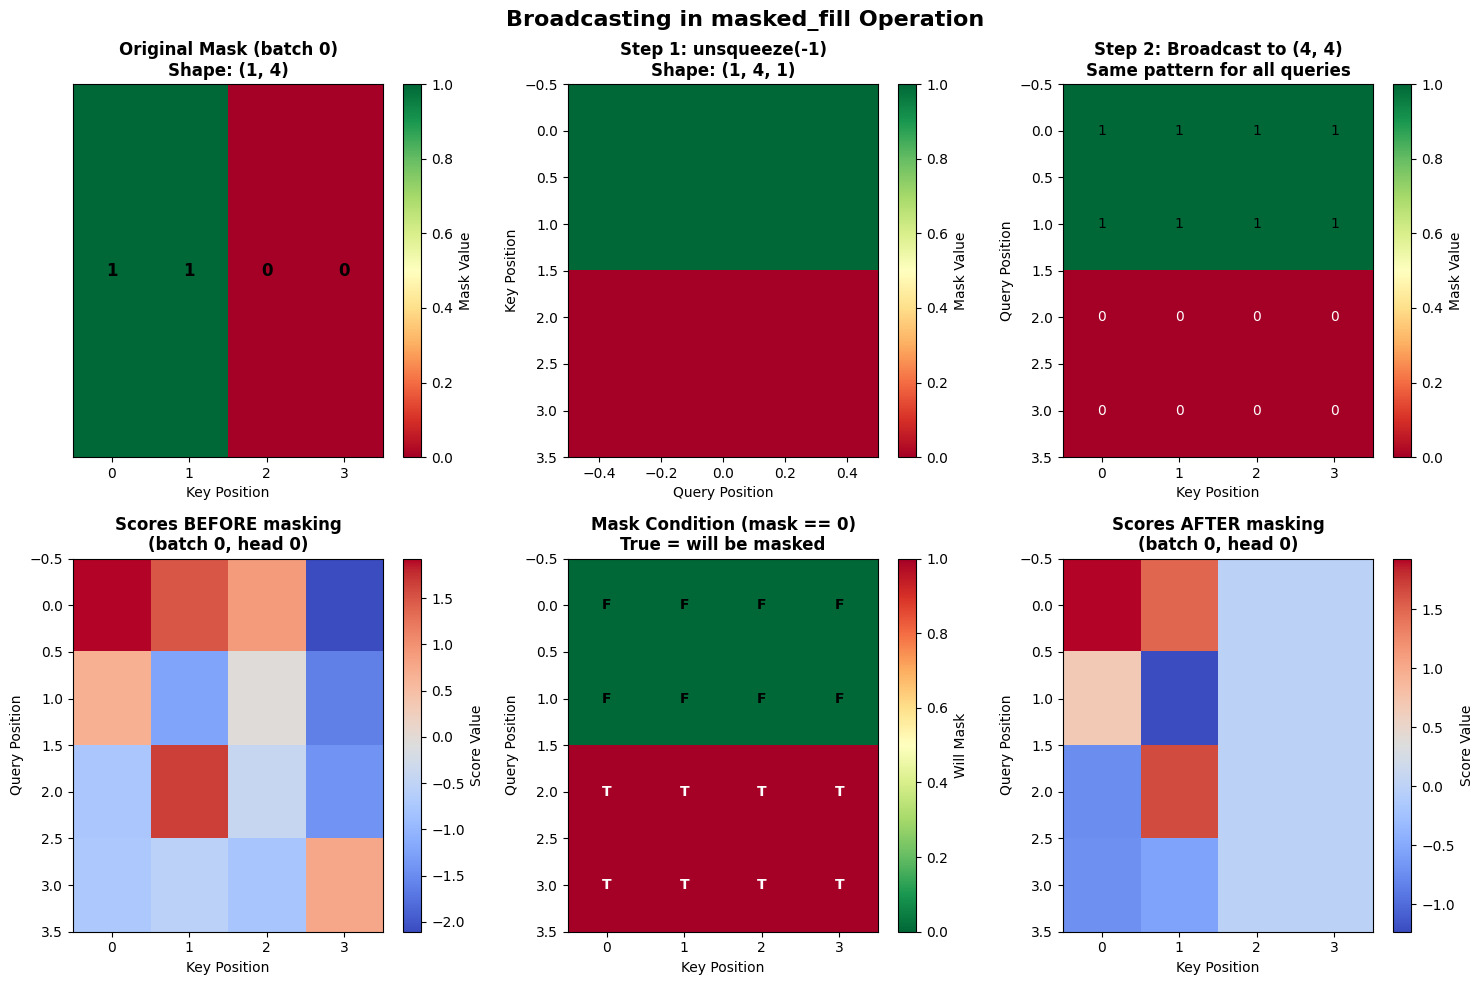


Key Observations:
--------------------------------------------------------------------------------
1. Original mask (1, 4) represents which KEY positions are valid
2. This pattern is repeated for EVERY QUERY position
3. Columns 2 and 3 are masked (padding tokens)
4. All queries see the same masking pattern



In [97]:
import torch
import matplotlib.pyplot as plt
import numpy as np

print("="*80)
print("BROADCASTING VISUALIZATION")
print("="*80)
print()

# Setup
batch_size, h, seq_len = 2, 2, 4
tokens = torch.randn(batch_size, seq_len)
tokens[0] = torch.tensor([1, 2, 0, 0])
tokens[1] = torch.tensor([1, 3, 4, 0])

mask = (tokens != 0).unsqueeze(-2)
torch.manual_seed(42)
scores = torch.randn(batch_size, h, seq_len, seq_len)

# ============================================================
# Visualize the broadcasting process
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Broadcasting in masked_fill Operation', fontsize=16, fontweight='bold')

# Original mask
ax = axes[0, 0]
mask_2d = mask[0].squeeze().numpy()
im = ax.imshow(mask_2d.reshape(1, -1), cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
ax.set_title('Original Mask (batch 0)\nShape: (1, 4)', fontweight='bold')
ax.set_xlabel('Key Position')
ax.set_yticks([])
for i in range(seq_len):
    ax.text(i, 0, f'{int(mask_2d[i])}', ha='center', va='center', fontsize=12, fontweight='bold')
plt.colorbar(im, ax=ax, label='Mask Value')

# Broadcast step 1: Add dimension
ax = axes[0, 1]
mask_expanded = mask[0].unsqueeze(-1).numpy()  # (1, 4, 1)
im = ax.imshow(mask_expanded.squeeze(0), cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
ax.set_title('Step 1: unsqueeze(-1)\nShape: (1, 4, 1)', fontweight='bold')
ax.set_xlabel('Query Position')
ax.set_ylabel('Key Position')
plt.colorbar(im, ax=ax, label='Mask Value')

# Broadcast step 2: Expand to full size
ax = axes[0, 2]
mask_full = mask[0].unsqueeze(-1).expand(1, seq_len, seq_len).squeeze(0).numpy()
im = ax.imshow(mask_full, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
ax.set_title('Step 2: Broadcast to (4, 4)\nSame pattern for all queries', fontweight='bold')
ax.set_xlabel('Key Position')
ax.set_ylabel('Query Position')
for i in range(seq_len):
    for j in range(seq_len):
        ax.text(j, i, f'{int(mask_full[i, j])}', ha='center', va='center', 
                fontsize=10, color='black' if mask_full[i, j] else 'white')
plt.colorbar(im, ax=ax, label='Mask Value')

# Scores before masking
ax = axes[1, 0]
scores_np = scores[0, 0].numpy()
im = ax.imshow(scores_np, cmap='coolwarm', aspect='auto')
ax.set_title('Scores BEFORE masking\n(batch 0, head 0)', fontweight='bold')
ax.set_xlabel('Key Position')
ax.set_ylabel('Query Position')
plt.colorbar(im, ax=ax, label='Score Value')

# Mask condition
ax = axes[1, 1]
mask_condition = (mask[0].unsqueeze(-1).expand(1, seq_len, seq_len) == 0).squeeze(0).numpy()
im = ax.imshow(mask_condition, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=1)
ax.set_title('Mask Condition (mask == 0)\nTrue = will be masked', fontweight='bold')
ax.set_xlabel('Key Position')
ax.set_ylabel('Query Position')
for i in range(seq_len):
    for j in range(seq_len):
        ax.text(j, i, 'T' if mask_condition[i, j] else 'F', 
                ha='center', va='center', fontsize=10, fontweight='bold',
                color='white' if mask_condition[i, j] else 'black')
plt.colorbar(im, ax=ax, label='Will Mask')

# Scores after masking
ax = axes[1, 2]
scores_masked = scores.masked_fill(mask == 0, 0.0)
scores_masked_np = scores_masked[0, 0].numpy()
im = ax.imshow(scores_masked_np, cmap='coolwarm', aspect='auto')
ax.set_title('Scores AFTER masking\n(batch 0, head 0)', fontweight='bold')
ax.set_xlabel('Key Position')
ax.set_ylabel('Query Position')
plt.colorbar(im, ax=ax, label='Score Value')

plt.tight_layout()
plt.savefig('broadcasting_visualization.png', dpi=150, bbox_inches='tight')
print("✓ Visualization saved as 'broadcasting_visualization.png'")
plt.show()

print()
print("Key Observations:")
print("-"*80)
print("1. Original mask (1, 4) represents which KEY positions are valid")
print("2. This pattern is repeated for EVERY QUERY position")
print("3. Columns 2 and 3 are masked (padding tokens)")
print("4. All queries see the same masking pattern")
print()


In [84]:
batch_size = 1
num_heads = 2
seq_len = 5
d_k = 4

# create simple query, key, value tensors
query = torch.randn(batch_size, num_heads, seq_len, d_k)
key = torch.randn(batch_size, num_heads, seq_len, d_k)
value = torch.randn(batch_size, num_heads, seq_len, d_k)

# query = torch.randn(seq_len, d_k)
# key = torch.randn(seq_len, d_k)
# value = torch.randn(seq_len, d_k)
# Note: the mask shape should be (batch_size, 1, seq_len) for broadcasting in attention
mask = torch.randn(batch_size, seq_len).unsqueeze(-2)
print(f"mask shape: {mask.shape}")


print("Q shape:", query.shape)
print("K shape", key.shape)
print("V shape:", value.shape)
print("K transpose(-2, 1) shape", key.transpose(-2, -1).shape)
print("mask shape:", mask.shape)

output, attention_weights = attention(query, key, value, mask)
print(f"Output shape:{output.shape}")
print(f"Attention weights shape: {attention_weights.shape}")
print(f"Attention weights (how much each token attends to others):\n{attention_weights.squeeze()}")
print(f"Sum of attention weights per row (should be ~1.0):{attention_weights.squeeze().sum(dim=-1)}")   

mask shape: torch.Size([1, 1, 5])
Q shape: torch.Size([1, 2, 5, 4])
K shape torch.Size([1, 2, 5, 4])
V shape: torch.Size([1, 2, 5, 4])
K transpose(-2, 1) shape torch.Size([1, 2, 4, 5])
mask shape: torch.Size([1, 1, 5])
+attention
scores shape: torch.Size([1, 2, 5, 5])
scores shape: torch.Size([1, 2, 5, 5])
attn shape: torch.Size([1, 2, 5, 5])
out shape: torch.Size([1, 2, 5, 4])
-attention
Output shape:torch.Size([1, 2, 5, 4])
Attention weights shape: torch.Size([1, 2, 5, 5])
Attention weights (how much each token attends to others):
tensor([[[0.0810, 0.3595, 0.0431, 0.0358, 0.4806],
         [0.0442, 0.1916, 0.1126, 0.2209, 0.4306],
         [0.0710, 0.5542, 0.1642, 0.1299, 0.0808],
         [0.4009, 0.1437, 0.2187, 0.1279, 0.1088],
         [0.2953, 0.1488, 0.2317, 0.1747, 0.1495]],

        [[0.2036, 0.0509, 0.0912, 0.5469, 0.1074],
         [0.0197, 0.1091, 0.1212, 0.4195, 0.3305],
         [0.0495, 0.0581, 0.1042, 0.5731, 0.2151],
         [0.1780, 0.4880, 0.1673, 0.0739, 0.0929],


In [ ]:
class MultiHeadAttentionD(nn.Module):
    def __init__(self, d_model, h, dropout=0.1):
        super(MultiHeadAttentionD, self).__init__()
        assert d_model % h == 0
        self.d_k = d_model // h
        self.h = h
        # 4 linear layers: Q, K, V projections + output projection
        self.linears = nn.ModuleList([nn.Linear(d_model, d_model) for _ in range(4)])
        self.attn = None
        self.dropout = nn.Dropout(p=dropout)
    
    # def forward(self, query, key, value, mask=None):
    def forward(self, x, mask=None):
        # batch_size = query.size(0)
        # x shape (batch_size, seq_len, d_model)
        print(f"x shape: {x.shape}")
        batch_size = x.size(0)
        #
        # zip(self.linears, (query, key, value))
        #   takes multiple iterables and pairs their elements together, 
        #   returns an iterator of tuples, stop when shortest iterable is exhausted
        #
        DEBUG = True
        if DEBUG:
            results = []
            names = ['query', 'key', 'value']
            # for i, (l, x) in enumerate(zip(self.linears, (x, x, x))):
            for i , l in enumerate(self.linears[:3]):
                print(f"Processing {names[i]}: input shape {x.shape}")
                # Apply linear transformation
                step1 = l(x)
                print(f"  After linear projection: {step1.shape}")
                # Reshape to (batch_size, seq_len, h, d_k)
                step2 = step1.view(batch_size, -1, self.h, self.d_k)
                print(f"  After view(batch, -1, h, d_k): {step2.shape}")
                # Transpose from (batch_size, seq_len, h, d_k) to (batch_size, h, seq_len, d_k)
                step3 = step2.transpose(1, 2)
                print(f"  After transpose(1, 2): {step3.shape}")
                results.append(step3)
            Q, K, V = results
            print(f"Q/K/V shape: {Q.shape}")
        
        # 1) Linear projections in batch from d_model => h x d_k for Q, K, V
        # query, key, value = [l(x).view(batch_size, -1, self.h, self.d_k).transpose(1, 2)
        #                      for l, x in zip(self.linears, (query, key, value))]
        # query, key, value shape (batch_size, h, seq_len, d_k)
        query, key, value = [l(x).view(batch_size, -1, self.h, self.d_k).transpose(1, 2)
                             for l in self.linears[:3]]
        print(f"query/key/value shape: {Q.shape}")

        # 2) apply attention on all the projected vectors in batch
        # x shape (batch_size, h, seq_len, d_k)
        x, self.attn = attention(query, key, value, mask, self.dropout)
        print(f"x after attention shape: {x.shape} att shape: {self.attn.shape}")
        
        # 3) "Concat" using a view and apply a final linear projection
        # x_transpose shape (batch_size, seq_len, h, d_k)
        x_transpose = x.transpose(1, 2).contiguous()
        print(f"x after transpose(1, 2): {x_transpose.shape}")
        # x_concat shape (batch_size, seq_len, h * d_k)
        x_concat = x_transpose.view(batch_size, -1, self.h * self.d_k)
        print(f"x after concat: {x_concat.shape}")

        # out shape (batch_size, seq_len, d_model)
        out = self.linears[-1](x_concat)
        print(f"out (apply linear on x after concat): {out.shape}")
        
        return out

In [ ]:
class MultiHeadAttention(nn.Module):
    """Multi-head attention: d_model dimensional, h heads
                           ┌─────────┐
                           │ Linear  │
                           └────▲────┘
                                │
                           ┌────┴────┐
                           │ Concat  │
                           └────▲────┘
                                │
        ┌─────────────────────────────────────────┐
        │     Scaled Dot-Product Attention        │   × h
        └─────────────────────────────────────────┘
             ▲                ▲                ▲
             │                │                │
         ┌───┴───┐        ┌───┴───┐        ┌───┴───┐
         │ Linear│        │ Linear│        │ Linear│
         └───▲───┘        └───▲───┘        └───▲───┘
             │                │                │
             V                K                Q
    """
    def __init__(self, d_model, h, dropout=0.1):
        super(MultiHeadAttention, self).__init__()
        assert d_model % h == 0
        self.h = h
        self.d_k = d_model // h
        # 4 linear layers: Q, K, V projections + output projection
        self.linears = nn.ModuleList([nn.Linear(in_features=d_model, out_features=d_model) for _ in range(4)])
        self.dropout = nn.Dropout(p=dropout)
        # store the probability score for visualization
        self.attn = None
    
    def forward(self, query, key, value, mask=None):
        print(f"+multi-head attention: input shape:{list(query.shape)}")
        # query, key, value shape (batch_size, seq_len, d_model)
        batch_size = query.size(0)
        # 1) Linear projections
        #    q_p, k_p, v_p shape (batch_size, h, seq_len, d_k)
        q_p, k_p, v_p = [l(x).view(batch_size, -1, self.h, self.d_k).transpose(1, 2)
                        for l, x in zip(self.linears, (query, key, value))]
        # 2) h times attention (in parallel)
        # concat_attn shape (batch_size, h, seq_len, d_k)
        concat_attn, self.attn = attention(q_p, k_p, v_p, mask, self.dropout)
        # 3) Concat
        # reshape to (batch_size, seq_len, h, d_k)
        concat_attn = concat_attn.transpose(1, 2).contiguous().view(batch_size, -1, self.h * self.d_k)
        # concat to (batch_size, seq_len, d_model(h * d_k))
        # concat_attn = concat_attn.view(batch_size, -1, self.h * self.d_k)
        # 4) linear
        # out shape (batch_size, seq_len, d_model)
        out = self.linears[-1](concat_attn)
        print(f"-multi-head attention: output shape:{list(out.shape)}")
        return out

In [60]:
batch_size, seq_len, d_model, h = 2, 10, 512, 8
print(f"batch_size:{batch_size} seq_len:{seq_len} d_model:{d_model} h:{h}")
mht = MultiHeadAttention(d_model=512, h=8)
x = torch.randn(batch_size, seq_len, d_model)
attentions = mht(x, x, x)

batch_size:2 seq_len:10 d_model:512 h:8
+multi-head attention: input shape:[2, 10, 512]
+attention
scores shape: torch.Size([2, 8, 10, 10])
attn shape: torch.Size([2, 8, 10, 10])
out shape: torch.Size([2, 8, 10, 64])
-attention
-multi-head attention: output shape:[2, 10, 512]


VISUALIZATION 2: Model Architecture (torchview)
+multi-head attention: input shape:[2, 10, 512]
+attention
scores shape: torch.Size([2, 8, 10, 10])
attn shape: torch.Size([2, 8, 10, 10])
out shape: torch.Size([2, 8, 10, 64])
-attention
-multi-head attention: output shape:[2, 10, 512]
✓ Architecture diagram saved as 'multi_head_attention_architecture.png'
✓ Model graph object created


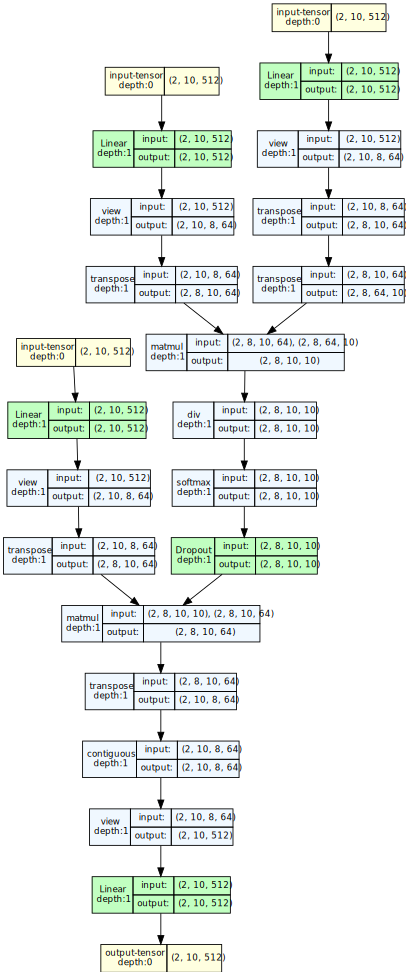

In [61]:
from torchview import draw_graph
# ============================================================
# Visualization 2: Model Architecture with torchview
# ============================================================
print("=" * 60)
print("VISUALIZATION 2: Model Architecture (torchview)")
print("=" * 60)
try:
    model_graph = draw_graph(
        mht,
        input_data=(x, x, x),
        graph_dir='TB', # Horizontal layout
                        # 'TB'	Top to Bottom	Vertical (default)
                        # 'LR'	Left to Right	Horizontal
                        # 'BT'	Bottom to Top	Vertical (reversed)
                        # 'RL'	Right to Left	Horizontal (reversed)
        expand_nested=True,
        graph_name='Multi-head attention',
        save_graph=True,
        filename='multi_head_attention_architecture',
        directory='.'
    )
    
    print("✓ Architecture diagram saved as 'multi_head_attention_architecture.png'")
    print(f"✓ Model graph object created")
    
    # Display visual graph
    display(model_graph.visual_graph)
    
except Exception as e:
    print(f"✗ Failed to generate architecture diagram: {e}")

print()

1.Detailed Architecture: Shows all components and connections
2.Shape Flow: Focuses on tensor shape transformations
3.Parallel Heads: Emphasizes the parallel nature of multi-head attention
4.Single Head: Details what happens in one attention head
5.Complete Flow: End-to-end with actual dimensions
6.Summary Table: Text-based reference

Visualization saved as 'multihead_attention_architecture.png'


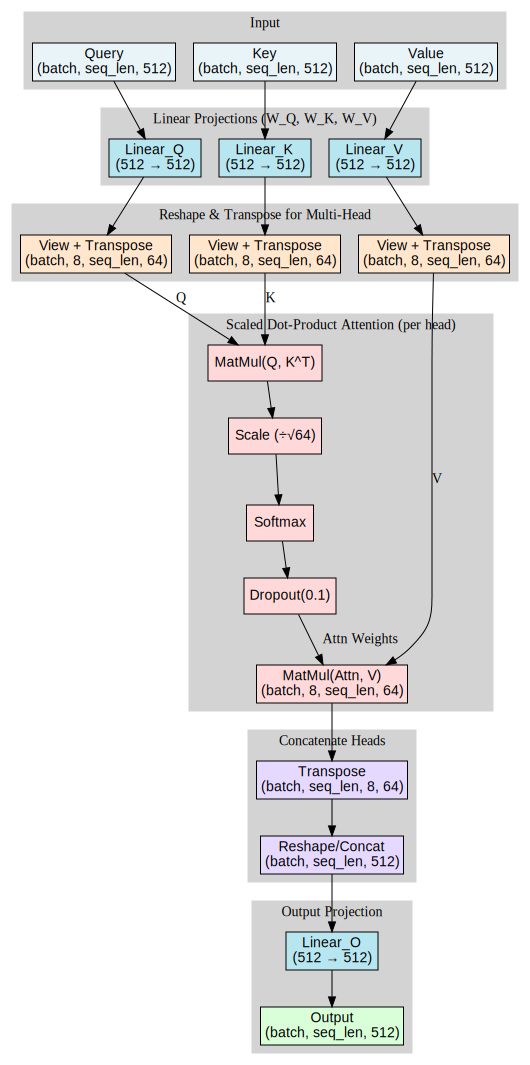

[33440:33440:0415/100130.293630:ERROR:ui/ozone/platform/x11/ozone_platform_x11.cc:256] Missing X server or $DISPLAY
[33440:33440:0415/100130.293660:ERROR:ui/aura/env.cc:246] The platform failed to initialize.  Exiting.


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from graphviz import Digraph

def attention(query, key, value, mask=None, dropout=None):
    d_k = query.size(-1)
    scores = torch.matmul(query, key.transpose(-2, -1)) / math.sqrt(d_k)
    p_attn = F.softmax(scores, dim=-1)
    if dropout is not None:
        p_attn = dropout(p_attn)
    return torch.matmul(p_attn, value), p_attn

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, h, dropout=0.1):
        super(MultiHeadAttention, self).__init__()
        assert d_model % h == 0
        self.d_k = d_model // h
        self.h = h
        self.linears = nn.ModuleList([nn.Linear(d_model, d_model) for _ in range(4)])
        self.attn = None
        self.dropout = nn.Dropout(p=dropout)
        
    def forward(self, query, key, value, mask=None):
        nbatches = query.size(0)
        
        query, key, value = [l(x).view(nbatches, -1, self.h, self.d_k).transpose(1, 2)
                             for l, x in zip(self.linears, (query, key, value))]
        
        x, self.attn = attention(query, key, value, mask=mask, dropout=self.dropout)
        
        x = x.transpose(1, 2).contiguous().view(nbatches, -1, self.h * self.d_k)
        
        return self.linears[-1](x)

def visualize_multihead_attention(d_model=512, h=8):
    """Create a detailed visualization of Multi-Head Attention architecture"""
    
    dot = Digraph(comment='Multi-Head Attention', format='png')
    dot.attr(rankdir='TB', size='12,16')
    dot.attr('node', shape='box', style='filled', fontname='Arial')
    
    # Color scheme
    input_color = '#E8F4F8'
    linear_color = '#B8E6F0'
    reshape_color = '#FFE6CC'
    attention_color = '#FFD9D9'
    concat_color = '#E6D9FF'
    output_color = '#D9FFD9'
    
    d_k = d_model // h
    
    # Input layer
    with dot.subgraph(name='cluster_input') as c:
        c.attr(label='Input', style='filled', color='lightgrey')
        c.node('query_in', f'Query\n(batch, seq_len, {d_model})', fillcolor=input_color)
        c.node('key_in', f'Key\n(batch, seq_len, {d_model})', fillcolor=input_color)
        c.node('value_in', f'Value\n(batch, seq_len, {d_model})', fillcolor=input_color)
    
    # Linear projections
    with dot.subgraph(name='cluster_linear') as c:
        c.attr(label='Linear Projections (W_Q, W_K, W_V)', style='filled', color='lightgrey')
        c.node('linear_q', f'Linear_Q\n({d_model} → {d_model})', fillcolor=linear_color)
        c.node('linear_k', f'Linear_K\n({d_model} → {d_model})', fillcolor=linear_color)
        c.node('linear_v', f'Linear_V\n({d_model} → {d_model})', fillcolor=linear_color)
    
    # Reshape for multi-head
    with dot.subgraph(name='cluster_reshape') as c:
        c.attr(label='Reshape & Transpose for Multi-Head', style='filled', color='lightgrey')
        c.node('reshape_q', f'View + Transpose\n(batch, {h}, seq_len, {d_k})', fillcolor=reshape_color)
        c.node('reshape_k', f'View + Transpose\n(batch, {h}, seq_len, {d_k})', fillcolor=reshape_color)
        c.node('reshape_v', f'View + Transpose\n(batch, {h}, seq_len, {d_k})', fillcolor=reshape_color)
    
    # Scaled Dot-Product Attention
    with dot.subgraph(name='cluster_attention') as c:
        c.attr(label='Scaled Dot-Product Attention (per head)', style='filled', color='lightgrey')
        c.node('matmul1', f'MatMul(Q, K^T)', fillcolor=attention_color)
        c.node('scale', f'Scale (÷√{d_k})', fillcolor=attention_color)
        c.node('softmax', 'Softmax', fillcolor=attention_color)
        c.node('dropout_attn', f'Dropout({0.1})', fillcolor=attention_color)
        c.node('matmul2', f'MatMul(Attn, V)\n(batch, {h}, seq_len, {d_k})', fillcolor=attention_color)
    
    # Concatenate heads
    with dot.subgraph(name='cluster_concat') as c:
        c.attr(label='Concatenate Heads', style='filled', color='lightgrey')
        c.node('transpose_back', f'Transpose\n(batch, seq_len, {h}, {d_k})', fillcolor=concat_color)
        c.node('concat', f'Reshape/Concat\n(batch, seq_len, {d_model})', fillcolor=concat_color)
    
    # Output projection
    with dot.subgraph(name='cluster_output') as c:
        c.attr(label='Output Projection', style='filled', color='lightgrey')
        c.node('linear_out', f'Linear_O\n({d_model} → {d_model})', fillcolor=linear_color)
        c.node('output', f'Output\n(batch, seq_len, {d_model})', fillcolor=output_color)
    
    # Connections - Input to Linear
    dot.edge('query_in', 'linear_q')
    dot.edge('key_in', 'linear_k')
    dot.edge('value_in', 'linear_v')
    
    # Linear to Reshape
    dot.edge('linear_q', 'reshape_q')
    dot.edge('linear_k', 'reshape_k')
    dot.edge('linear_v', 'reshape_v')
    
    # Reshape to Attention
    dot.edge('reshape_q', 'matmul1', label='Q')
    dot.edge('reshape_k', 'matmul1', label='K')
    dot.edge('reshape_v', 'matmul2', label='V')
    
    # Attention flow
    dot.edge('matmul1', 'scale')
    dot.edge('scale', 'softmax')
    dot.edge('softmax', 'dropout_attn')
    dot.edge('dropout_attn', 'matmul2', label='Attn Weights')
    
    # Attention to Concat
    dot.edge('matmul2', 'transpose_back')
    dot.edge('transpose_back', 'concat')
    
    # Concat to Output
    dot.edge('concat', 'linear_out')
    dot.edge('linear_out', 'output')
    
    return dot

# Create visualization
dot = visualize_multihead_attention(d_model=512, h=8)
dot.render('multihead_attention_architecture', view=True, cleanup=True)
print("Visualization saved as 'multihead_attention_architecture.png'")
dot


Simplified visualization saved as 'mha_shape_flow.png'


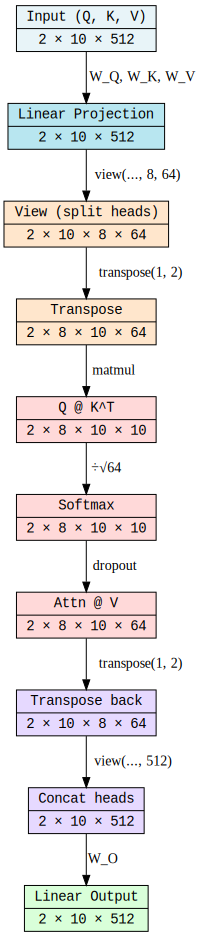

[25353:25353:0414/160426.167430:ERROR:ui/ozone/platform/x11/ozone_platform_x11.cc:256] Missing X server or $DISPLAY
[25353:25353:0414/160426.167458:ERROR:ui/aura/env.cc:246] The platform failed to initialize.  Exiting.


In [ ]:
from graphviz import Digraph

def visualize_mha_simple(batch_size=2, seq_len=10, d_model=512, h=8):
    """Simplified visualization focusing on shape transformations"""
    
    dot = Digraph(comment='MHA Shape Flow', format='png')
    dot.attr(rankdir='TB', size='10,14')
    dot.attr('node', shape='record', style='filled', fontname='Courier')
    
    d_k = d_model // h
    
    # Define shapes at each stage
    shapes = {
        'input': f'{batch_size} × {seq_len} × {d_model}',
        'after_linear': f'{batch_size} × {seq_len} × {d_model}',
        'after_view': f'{batch_size} × {seq_len} × {h} × {d_k}',
        'after_transpose': f'{batch_size} × {h} × {seq_len} × {d_k}',
        'scores': f'{batch_size} × {h} × {seq_len} × {seq_len}',
        'attn_output': f'{batch_size} × {h} × {seq_len} × {d_k}',
        'after_transpose_back': f'{batch_size} × {seq_len} × {h} × {d_k}',
        'after_concat': f'{batch_size} × {seq_len} × {d_model}',
        'final_output': f'{batch_size} × {seq_len} × {d_model}',
    }
    
    # Nodes with shapes
    dot.node('0', f'{{Input (Q, K, V)|{shapes["input"]}}}', fillcolor='#E8F4F8')
    dot.node('1', f'{{Linear Projection|{shapes["after_linear"]}}}', fillcolor='#B8E6F0')
    dot.node('2', f'{{View (split heads)|{shapes["after_view"]}}}', fillcolor='#FFE6CC')
    dot.node('3', f'{{Transpose|{shapes["after_transpose"]}}}', fillcolor='#FFE6CC')
    dot.node('4', f'{{Q @ K^T|{shapes["scores"]}}}', fillcolor='#FFD9D9')
    dot.node('5', f'{{Softmax|{shapes["scores"]}}}', fillcolor='#FFD9D9')
    dot.node('6', f'{{Attn @ V|{shapes["attn_output"]}}}', fillcolor='#FFD9D9')
    dot.node('7', f'{{Transpose back|{shapes["after_transpose_back"]}}}', fillcolor='#E6D9FF')
    dot.node('8', f'{{Concat heads|{shapes["after_concat"]}}}', fillcolor='#E6D9FF')
    dot.node('9', f'{{Linear Output|{shapes["final_output"]}}}', fillcolor='#D9FFD9')
    
    # Edges
    dot.edge('0', '1', label='W_Q, W_K, W_V')
    dot.edge('1', '2', label=f'view(..., {h}, {d_k})')
    dot.edge('2', '3', label='transpose(1, 2)')
    dot.edge('3', '4', label='matmul')
    dot.edge('4', '5', label=f'÷√{d_k}')
    dot.edge('5', '6', label='dropout')
    dot.edge('6', '7', label='transpose(1, 2)')
    dot.edge('7', '8', label=f'view(..., {d_model})')
    dot.edge('8', '9', label='W_O')
    
    return dot

# Create simplified visualization
dot_simple = visualize_mha_simple(batch_size=2, seq_len=10, d_model=512, h=8)
dot_simple.render('mha_shape_flow', view=True, cleanup=True)
print("Simplified visualization saved as 'mha_shape_flow.png'")
dot_simple


Parallel heads visualization saved as 'mha_parallel_heads.png'


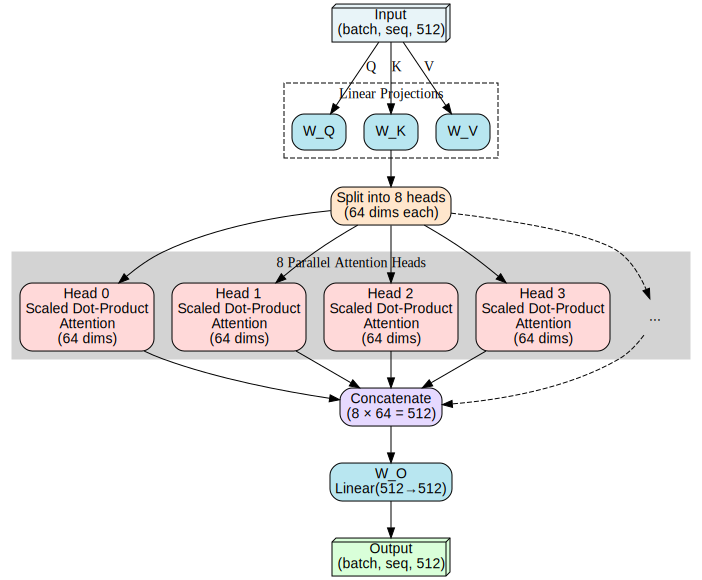

[25419:25419:0414/160454.855277:ERROR:ui/ozone/platform/x11/ozone_platform_x11.cc:256] Missing X server or $DISPLAY
[25419:25419:0414/160454.855304:ERROR:ui/aura/env.cc:246] The platform failed to initialize.  Exiting.


In [ ]:
from graphviz import Digraph

def visualize_mha_parallel_heads(d_model=512, h=8):
    """Visualization showing parallel attention heads"""
    
    dot = Digraph(comment='Multi-Head Attention Parallel', format='png')
    dot.attr(rankdir='TB', size='14,10')
    dot.attr('node', shape='box', style='filled,rounded', fontname='Arial')
    
    d_k = d_model // h
    
    # Input
    dot.node('input', f'Input\n(batch, seq, {d_model})', fillcolor='#E8F4F8', shape='box3d')
    
    # Linear projections
    with dot.subgraph(name='cluster_proj') as c:
        c.attr(label='Linear Projections', style='dashed')
        c.node('Wq', f'W_Q', fillcolor='#B8E6F0')
        c.node('Wk', f'W_K', fillcolor='#B8E6F0')
        c.node('Wv', f'W_V', fillcolor='#B8E6F0')
    
    dot.edge('input', 'Wq', label='Q')
    dot.edge('input', 'Wk', label='K')
    dot.edge('input', 'Wv', label='V')
    
    # Split into heads
    dot.node('split', f'Split into {h} heads\n({d_k} dims each)', fillcolor='#FFE6CC')
    dot.edge('Wq', 'split', style='invis')
    dot.edge('Wk', 'split')
    dot.edge('Wv', 'split', style='invis')
    
    # Parallel attention heads
    with dot.subgraph(name='cluster_heads') as c:
        c.attr(label=f'{h} Parallel Attention Heads', style='filled', color='lightgrey')
        
        for i in range(min(h, 4)):  # Show first 4 heads
            head_name = f'head{i}'
            c.node(head_name, 
                   f'Head {i}\nScaled Dot-Product\nAttention\n({d_k} dims)',
                   fillcolor='#FFD9D9')
            dot.edge('split', head_name)
        
        if h > 4:
            c.node('head_dots', '...', shape='plaintext')
            dot.edge('split', 'head_dots', style='dashed')
    
    # Concatenate
    dot.node('concat', f'Concatenate\n({h} × {d_k} = {d_model})', fillcolor='#E6D9FF')
    
    for i in range(min(h, 4)):
        dot.edge(f'head{i}', 'concat')
    if h > 4:
        dot.edge('head_dots', 'concat', style='dashed')
    
    # Output projection
    dot.node('Wo', f'W_O\nLinear({d_model}→{d_model})', fillcolor='#B8E6F0')
    dot.node('output', f'Output\n(batch, seq, {d_model})', fillcolor='#D9FFD9', shape='box3d')
    
    dot.edge('concat', 'Wo')
    dot.edge('Wo', 'output')
    
    return dot

# Create parallel heads visualization
dot_parallel = visualize_mha_parallel_heads(d_model=512, h=8)
dot_parallel.render('mha_parallel_heads', view=True, cleanup=True)
print("Parallel heads visualization saved as 'mha_parallel_heads.png'")
dot_parallel


Single head visualization saved as 'single_attention_head.png'


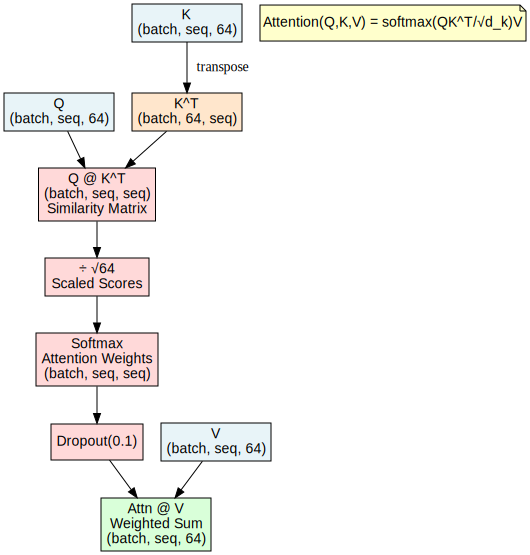

[25487:25487:0414/160544.256968:ERROR:ui/ozone/platform/x11/ozone_platform_x11.cc:256] Missing X server or $DISPLAY
[25487:25487:0414/160544.256992:ERROR:ui/aura/env.cc:246] The platform failed to initialize.  Exiting.


In [ ]:
from graphviz import Digraph

def visualize_single_attention_head(d_k=64):
    """Detailed view of a single attention head"""
    
    dot = Digraph(comment='Single Attention Head', format='png')
    dot.attr(rankdir='TB', size='8,10')
    dot.attr('node', shape='box', style='filled', fontname='Arial')
    
    # Inputs
    dot.node('Q', f'Q\n(batch, seq, {d_k})', fillcolor='#E8F4F8')
    dot.node('K', f'K\n(batch, seq, {d_k})', fillcolor='#E8F4F8')
    dot.node('V', f'V\n(batch, seq, {d_k})', fillcolor='#E8F4F8')
    
    # Transpose K
    dot.node('K_T', f'K^T\n(batch, {d_k}, seq)', fillcolor='#FFE6CC')
    dot.edge('K', 'K_T', label='transpose')
    
    # Q @ K^T
    dot.node('QK', f'Q @ K^T\n(batch, seq, seq)\nSimilarity Matrix', fillcolor='#FFD9D9')
    dot.edge('Q', 'QK')
    dot.edge('K_T', 'QK')
    
    # Scale
    dot.node('scale', f'÷ √{d_k}\nScaled Scores', fillcolor='#FFD9D9')
    dot.edge('QK', 'scale')
    
    # Softmax
    dot.node('softmax', f'Softmax\nAttention Weights\n(batch, seq, seq)', fillcolor='#FFD9D9')
    dot.edge('scale', 'softmax')
    
    # Dropout
    dot.node('dropout', 'Dropout(0.1)', fillcolor='#FFD9D9')
    dot.edge('softmax', 'dropout')
    
    # Attention @ V
    dot.node('output', f'Attn @ V\nWeighted Sum\n(batch, seq, {d_k})', fillcolor='#D9FFD9')
    dot.edge('dropout', 'output')
    dot.edge('V', 'output')
    
    # Add formula annotation
    dot.node('formula', 
             'Attention(Q,K,V) = softmax(QK^T/√d_k)V',
             shape='note', fillcolor='#FFFFCC')
    
    return dot

# Create single head visualization
dot_single = visualize_single_attention_head(d_k=64)
dot_single.render('single_attention_head', view=True, cleanup=True)
print("Single head visualization saved as 'single_attention_head.png'")
dot_single


Complete flow visualization saved as 'mha_complete_flow.png'


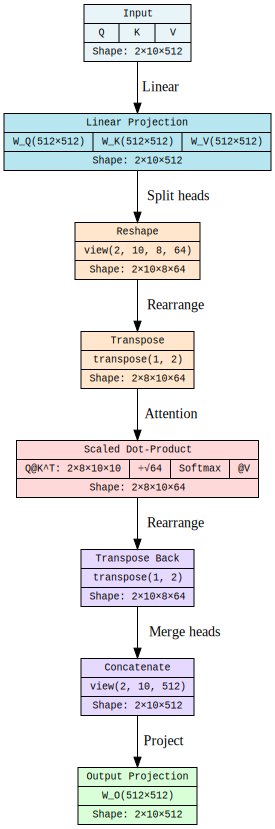

[25641:25641:0414/160654.541174:ERROR:ui/ozone/platform/x11/ozone_platform_x11.cc:256] Missing X server or $DISPLAY
[25641:25641:0414/160654.541206:ERROR:ui/aura/env.cc:246] The platform failed to initialize.  Exiting.


In [ ]:
from graphviz import Digraph

def visualize_complete_mha_flow():
    """Complete flow with actual example values"""
    
    dot = Digraph(comment='Complete MHA Flow', format='png')
    dot.attr(rankdir='TB', size='16,12')
    dot.attr('node', shape='record', style='filled', fontname='Courier New', fontsize='10')
    
    # Stage 1: Input
    dot.node('stage1', 
             '{Input|{Q|K|V}|Shape: 2×10×512}',
             fillcolor='#E8F4F8')
    
    # Stage 2: Linear Projection
    dot.node('stage2',
             '{Linear Projection|{W_Q(512×512)|W_K(512×512)|W_V(512×512)}|Shape: 2×10×512}',
             fillcolor='#B8E6F0')
    
    # Stage 3: Reshape
    dot.node('stage3',
             '{Reshape|view(2, 10, 8, 64)|Shape: 2×10×8×64}',
             fillcolor='#FFE6CC')
    
    # Stage 4: Transpose
    dot.node('stage4',
             '{Transpose|transpose(1, 2)|Shape: 2×8×10×64}',
             fillcolor='#FFE6CC')
    
    # Stage 5: Attention
    dot.node('stage5',
             '{Scaled Dot-Product|{Q@K^T: 2×8×10×10|÷√64|Softmax|@V}|Shape: 2×8×10×64}',
             fillcolor='#FFD9D9')
    
    # Stage 6: Transpose back
    dot.node('stage6',
             '{Transpose Back|transpose(1, 2)|Shape: 2×10×8×64}',
             fillcolor='#E6D9FF')
    
    # Stage 7: Concat
    dot.node('stage7',
             '{Concatenate|view(2, 10, 512)|Shape: 2×10×512}',
             fillcolor='#E6D9FF')
    
    # Stage 8: Output
    dot.node('stage8',
             '{Output Projection|W_O(512×512)|Shape: 2×10×512}',
             fillcolor='#D9FFD9')
    
    # Connections
    dot.edge('stage1', 'stage2', label='Linear')
    dot.edge('stage2', 'stage3', label='Split heads')
    dot.edge('stage3', 'stage4', label='Rearrange')
    dot.edge('stage4', 'stage5', label='Attention')
    dot.edge('stage5', 'stage6', label='Rearrange')
    dot.edge('stage6', 'stage7', label='Merge heads')
    dot.edge('stage7', 'stage8', label='Project')
    
    return dot

# Create complete flow visualization
dot_complete = visualize_complete_mha_flow()
dot_complete.render('mha_complete_flow', view=True, cleanup=True)
print("Complete flow visualization saved as 'mha_complete_flow.png'")
dot_complete


In [68]:
# Print a text-based summary
print("="*80)
print("MULTI-HEAD ATTENTION ARCHITECTURE SUMMARY")
print("="*80)
print()
print("Parameters: batch_size=2, seq_len=10, d_model=512, num_heads=8, d_k=64")
print()
print("-"*80)
print(f"{'Step':<5} {'Operation':<25} {'Input Shape':<20} {'Output Shape':<20}")
print("-"*80)

steps = [
    ("1", "Input (Q, K, V)", "-", "(2, 10, 512)"),
    ("2", "Linear W_Q, W_K, W_V", "(2, 10, 512)", "(2, 10, 512)"),
    ("3", "View (split heads)", "(2, 10, 512)", "(2, 10, 8, 64)"),
    ("4", "Transpose", "(2, 10, 8, 64)", "(2, 8, 10, 64)"),
    ("5", "Q @ K^T", "(2, 8, 10, 64)", "(2, 8, 10, 10)"),
    ("6", "Scale ÷√64", "(2, 8, 10, 10)", "(2, 8, 10, 10)"),
    ("7", "Softmax", "(2, 8, 10, 10)", "(2, 8, 10, 10)"),
    ("8", "Dropout", "(2, 8, 10, 10)", "(2, 8, 10, 10)"),
    ("9", "Attn @ V", "(2, 8, 10, 10)", "(2, 8, 10, 64)"),
    ("10", "Transpose back", "(2, 8, 10, 64)", "(2, 10, 8, 64)"),
    ("11", "View (concat heads)", "(2, 10, 8, 64)", "(2, 10, 512)"),
    ("12", "Linear W_O", "(2, 10, 512)", "(2, 10, 512)"),
]

for step, op, inp, out in steps:
    print(f"{step:<5} {op:<25} {inp:<20} {out:<20}")

print("-"*80)
print()
print("Key Transformations:")
print("  • Split: (batch, seq, d_model) → (batch, seq, h, d_k)")
print("  • Rearrange: (batch, seq, h, d_k) → (batch, h, seq, d_k)")
print("  • Attention: Creates (batch, h, seq, seq) similarity matrix")
print("  • Merge: (batch, h, seq, d_k) → (batch, seq, d_model)")
print("="*80)


MULTI-HEAD ATTENTION ARCHITECTURE SUMMARY

Parameters: batch_size=2, seq_len=10, d_model=512, num_heads=8, d_k=64

--------------------------------------------------------------------------------
Step  Operation                 Input Shape          Output Shape        
--------------------------------------------------------------------------------
1     Input (Q, K, V)           -                    (2, 10, 512)        
2     Linear W_Q, W_K, W_V      (2, 10, 512)         (2, 10, 512)        
3     View (split heads)        (2, 10, 512)         (2, 10, 8, 64)      
4     Transpose                 (2, 10, 8, 64)       (2, 8, 10, 64)      
5     Q @ K^T                   (2, 8, 10, 64)       (2, 8, 10, 10)      
6     Scale ÷√64                (2, 8, 10, 10)       (2, 8, 10, 10)      
7     Softmax                   (2, 8, 10, 10)       (2, 8, 10, 10)      
8     Dropout                   (2, 8, 10, 10)       (2, 8, 10, 10)      
9     Attn @ V                  (2, 8, 10, 10)       (2, 